In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold
import pickle

from notebooks.imports import *
from config import dir_config
from src.utils import pmf_utils, glm_hmm_utils

In [3]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [4]:
_TRIALS = "masked"
# _TRIALS = "masked_eq_prior_only"
# _TRIALS = "masked_uneq_prior_only"
# _TRIALS = "masked_no_bias"

In [5]:
data_path = f"glm_hmm_{_TRIALS}.pkl"

_EQUAL_ONLY = "_eq_prior_only" in _TRIALS
_UNEQUAL_ONLY = "_uneq_prior_only" in _TRIALS
no_bias = "_no_bias" in _TRIALS
n_trial_back = 1

#### utils

In [28]:
def psychometric_fit(stimulus, choices, expected_choice_prob, mask, ax, color, label, n_sample=10):
	data = {"signed_coherence": np.array(stimulus[mask]) * 100, "choice": choices[mask]}
	x_data, y_data, model, x_model, y_model = pmf_utils.get_psychometric_data(data)

	x_model_hat, y_model_hat = np.full((n_sample, len(x_model)), np.nan), np.full((n_sample, len(y_model)), np.nan)

	x_model_hat, y_model_hat = np.full((n_sample, len(x_model)), np.nan), np.full((n_sample, len(y_model)), np.nan)
	for idx_sample in range(n_sample):
		data_fitted = {"signed_coherence": np.array(stimulus[mask]) * 100, "choice": npr.binomial(1, expected_choice_prob[mask])}
		x_data, y_data_hat, _, x_model_hat[idx_sample, :], y_model_hat[idx_sample, :] = pmf_utils.get_psychometric_data(data_fitted)

	ax.plot(x_data, y_data, "o", color=color)
	ax.plot(x_model, y_model, color=color, label=label)
	ax.plot(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0), color=color, linestyle="--")
	ax.fill_between(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0) - np.std(y_model_hat, axis=0), np.mean(y_model_hat, axis=0) + np.std(y_model_hat, axis=0), color=color, alpha=0.3)

	ax.set_xlim(min(x_data), max(x_data))
	ax.set_xlabel("Coherence")
	ax.set_ylabel("choices toRF")
	ax.set_title("Psychometric fits", fontsize=15)
	ax.legend()

In [36]:
transition_matrix = model.transitions.params
transition_matrix = np.exp(transition_matrix)[0]
weights = -model.observations.params


In [37]:
posterior_probs, weighted_sum = [], []
for idx in train_idx:
    posterior_probs.append(model.expected_states(data=choices[idx], input=input[idx], mask=np.array(mask[idx]).reshape(-1, 1))[0])
    weighted_sum.append(np.sum(weights * input[idx][None, :, :], axis=-1).T)
sigmoid_output = 1 / (1 + np.exp(-np.concatenate(weighted_sum)))
glm_hmm_expected_choice_prob = np.sum(sigmoid_output * np.concatenate(posterior_probs), axis=1, keepdims=True)

In [41]:
equal_indices = np.where(mask)[0][:task_switch]
unequal_indices = np.where(mask)[0][task_switch:]
equal_indices = np.intersect1d(np.concatenate(train_idx), equal_indices)
unequal_indices = np.intersect1d(np.concatenate(train_idx), unequal_indices)

In [46]:
def get_state_and_choice_probabilities(model, choices, input, mask):
    transition_matrix = model.transitions.params
    transition_matrix = np.exp(transition_matrix)[0]
    weights = -model.observations.params
    posterior_probs= model.expected_states(data=choices, input=input, mask=np.array(mask).reshape(-1, 1))[0]
    weighted_sum = np.sum(weights * input[None, :, :], axis=-1).T
    sigmoid_output = 1 / (1 + np.exp(-weighted_sum))
    glm_hmm_expected_choice_prob = np.sum(sigmoid_output * posterior_probs, axis=1, keepdims=True)
    return posterior_probs, glm_hmm_expected_choice_prob

In [ ]:
temp_post, temp_choice_prob = get_state_and_choice_probabilities(model, choices[train_idx[0]], input[train_idx[0]], mask[train_idx[0]])

In [95]:
npr.binomial(1, np.concatenate(expected_choice_probs))

ValueError: p < 0, p > 1 or p contains NaNs

In [ ]:

def plot_psych(stimulus, choices, expected_choice_prob, ax, color, label, n_sample=10):

    data = {"signed_coherence": np.array(stimulus) * 100, "choice": choices}
    x_data, y_data, model, x_model, y_model = pmf_utils.get_psychometric_data(data)

    x_model_hat, y_model_hat = np.full((n_sample, len(x_model)), np.nan), np.full((n_sample, len(y_model)), np.nan)
    for idx_sample in range(n_sample):
        data_fitted = {"signed_coherence": np.array(stimulus) * 100, "choice": npr.binomial(1, expected_choice_prob)}
        x_data, y_data_hat, _, x_model_hat[idx_sample, :], y_model_hat[idx_sample, :] = pmf_utils.get_psychometric_data(data_fitted)

    ax.plot(x_data, y_data, "o", color=color)
    ax.plot(x_model, y_model, color=color, label=label)
    ax.plot(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0), color=color, linestyle="--")
    ax.fill_between(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0) - np.std(y_model_hat, axis=0), np.mean(y_model_hat, axis=0) + np.std(y_model_hat, axis=0), color=color, alpha=0.3)

    ax.set_xlim(min(x_data), max(x_data))
    ax.set_xlabel("Coherence")
    ax.set_ylabel("choices toRF")
    ax.set_title("Psychometric fits", fontsize=15)
    ax.legend()


In [111]:
def get_masked_block_indices(mask, task_switch, trial_idx):
    mask_idx = np.where(mask)[0]
    equal_masked = mask_idx[mask_idx < task_switch]
    unequal_masked = mask_idx[mask_idx >= task_switch]
    equal_trials= np.intersect1d(trial_idx, equal_masked)
    unequal_trials = np.intersect1d(trial_idx, unequal_masked)
    equal_indices = np.where(np.isin(trial_idx, equal_trials))[0]
    unequal_indices = np.where(np.isin(trial_idx, unequal_trials))[0]
    return equal_indices, unequal_indices


In [118]:
equal_indices

array([  0,   1,   3,   4,   5,   6,   7,   8,   9,  11,  13,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  26,  27,  28,  29,  30,
        31,  32,  33,  34,  35,  36,  38,  39,  40,  42,  43,  44,  45,
        46,  47,  49,  50,  51,  52,  53,  54,  55,  56,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
        75,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 135, 136, 138, 139, 140, 141, 142, 143, 144, 145,
       146, 147, 148, 149, 150, 151, 152, 153, 155, 157, 159, 160, 161,
       162, 163, 165, 166, 167, 168, 169, 172, 173, 174, 175, 176, 177,
       178, 181, 182, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,
       194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 20

In [117]:
stimulus[train_idx_array]#[equal_indices]

0       0.20
1      -0.50
2       0.00
3      -0.20
4       0.50
        ... 
1306    0.00
1307    0.50
1308     NaN
1309    0.50
1310    0.06
Name: stimulus, Length: 1051, dtype: float64

KeyError: '[195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 251, 252, 253, 254, 255, 256, 257, 259] not in index'

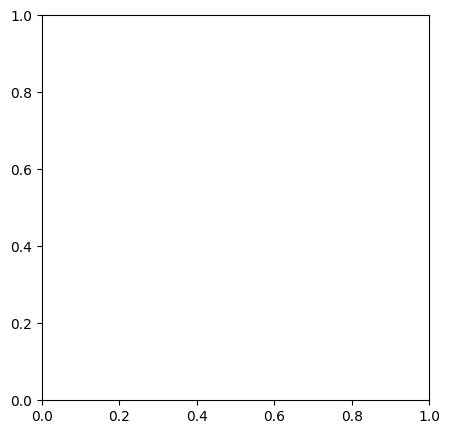

In [114]:
train_idx_array = np.concatenate(train_idx)
equal_indices, unequal_indices = get_masked_block_indices(mask, task_switch, train_idx_array)
fig,ax = plt.subplots(figsize=(5,5))
plot_psych(stimulus[train_idx_array][equal_indices], choices[train_idx_array][equal_indices], np.concatenate(expected_choice_probs)[equal_indices], ax, color='blue', label='Equal Prior')

In [ ]:
def plot_model_fits(model, choices, input, stimulus, mask, n_states, session_name, task_switch, trial_indices=None):
    """
        choices, input, stimulus, mask: list of array(s)
    """
    transition_matrix = model.transitions.params
    transition_matrix = np.exp(transition_matrix)[0]
    weights = -model.observations.params
    posterior_probs, weighted_sum = [], []
    for idx in trial_indices:
        posterior_probs.append(model.expected_states(data=choices[idx], input=input[idx], mask=np.array(mask[idx]).reshape(-1, 1))[0])
        weighted_sum.append(np.sum(weights * input[idx][None, :, :], axis=-1).T)
    sigmoid_output = 1 / (1 + np.exp(-np.concatenate(weighted_sum)))
    glm_hmm_expected_choice_prob = np.sum(sigmoid_output * np.concatenate(posterior_probs), axis=1, keepdims=True)



    plt.figure(figsize=(14, 4))  # Wider figure for better spacing
    gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 2])  # Merge last two subplots

    cols = ["#ff7f00", "#4daf4a", "#377eb8"]  # Add more colors if needed for higher n_states
    plt.suptitle(session_name)
    # ----  First Subplot: Psychometric Curves ----
    ax1 = plt.subplot(gs[0])

    if _EQUAL_ONLY and not _UNEQUAL_ONLY:
        equal_indices = np.where(mask)[0][:]
        if trial_indices is not None:
            equal_indices = np.intersect1d(np.concatenate(trial_indices), equal_indices)
        psychometric_fit(stimulus[equal_indices], choices[equal_indices], glm_hmm_expected_choice_prob[equal_indices], mask[equal_indices], ax1, "#377eb8", label="Equal")
    elif _UNEQUAL_ONLY:
        unequal_indices = np.where(mask)[0][:]
        if trial_indices is not None:
            unequal_indices = np.intersect1d(np.concatenate(trial_indices), unequal_indices)
        psychometric_fit(stimulus[unequal_indices], choices[unequal_indices], glm_hmm_expected_choice_prob[unequal_indices], mask[unequal_indices], ax1, "#974810", label="Unequal")
    elif not _EQUAL_ONLY and not _UNEQUAL_ONLY:
        equal_indices = np.where(mask)[0][:task_switch]
        unequal_indices = np.where(mask)[0][task_switch:]
        if trial_indices is not None:
            equal_indices = np.intersect1d(np.concatenate(trial_indices), equal_indices)
            unequal_indices = np.intersect1d(np.concatenate(trial_indices), unequal_indices)

        psychometric_fit(stimulus[equal_indices], choices[equal_indices], glm_hmm_expected_choice_prob[equal_indices], mask[equal_indices], ax1, "#377eb8", label="Equal")
        psychometric_fit(stimulus[unequal_indices], choices[unequal_indices], glm_hmm_expected_choice_prob[unequal_indices], mask[unequal_indices], ax1, "#974810", label="Unequal")
    else:
        raise ValueError("Invalid combination of _EQUAL_ONLY and _UNEQUAL_ONLY flags.")

    # ---- Second Subplot: GLM Weights ----
    ax2 = plt.subplot(gs[1])
    for k in range(n_states):
    	ax2.plot(np.arange(input.shape[1]), weights[k][0], marker="o", color=cols[k], linestyle="-", lw=1.5, label=f"State {k + 1}")

    ax2.tick_params(axis="y", labelsize=10)
    ax2.set_ylabel("GLM weight", fontsize=15)
    ax2.set_xlabel("covariate", fontsize=15)
    labels = ["Stimulus", "Bias"] \
    	+ [f"Prev Choice {t+1}" for t in range(n_trial_back)] \
    	+ [f"Prev Target {t+1}" for t in range(n_trial_back)]
    ax2.set_xticklabels(labels, fontsize=12, rotation=15)

    ax2.axhline(y=0, color="k", alpha=0.5, ls="--")
    ax2.legend()
    ax2.set_title("GLM weights", fontsize=15)

    # ---- Third Subplot: Transition Matrix ----
    ax3 = plt.subplot(gs[2])
    ax3.imshow(transition_matrix, vmin=-0.8, vmax=1, cmap="bone")
    for i in range(transition_matrix.shape[0]):
    	for j in range(transition_matrix.shape[1]):
    		ax3.text(j, i, str(np.around(transition_matrix[i, j], decimals=2)), ha="center", va="center", color="k", fontsize=12)

    ax3.set_xlim(-0.5, n_states - 0.5)
    ax3.set_ylim(n_states - 0.5, -0.5)
    ax3.set_xticks(range(n_states))
    ax3.set_yticks(range(n_states))
    ax3.set_xlabel("state t+1", fontsize=15)
    ax3.set_ylabel("state t", fontsize=15)
    ax3.set_title("Generative transition matrix", fontsize=15)

    # ---- Fourth (Merged) Subplot: Posterior Probabilities ----
    ax4 = plt.subplot(gs[3])  # Merged across two columns
    for k in range(n_states):
        ax4.plot(posterior_probs[mask, k], label=f"State {k + 1}", lw=2, color=cols[k])

    ax4.set_ylim(-0.01, 1.01)
    ax4.set_yticks([0, 0.5, 1])
    ax4.tick_params(axis="y", labelsize=10)
    ax4.set_xlabel("trial #", fontsize=15)
    ax4.set_ylabel("p(state)", fontsize=15)
    ax4.axvline(x=task_switch, color="k", alpha=0.5, ls="--")
    ax4.legend()
    ax4.set_title("Posterior Probabilities", fontsize=15)

    plt.tight_layout()
    plt.show()

#### Load Data

In [8]:
with open(Path(processed_dir, data_path), "rb") as f:
	glm_hmm = pickle.load(f)

session_metadata = pd.read_csv(Path(processed_dir, "sessions_metadata.csv"))

#### Best fold for each session

In [9]:
if _EQUAL_ONLY:
    best_state_idx = 0
else:
    best_state_idx = 1

best_state = best_state_idx + 1

In [10]:
best_fold_session_wise = []
for session in range(glm_hmm["session_wise"]["test_ll"].shape[0]):
	best_fold_session_wise.append(np.argmax(glm_hmm["session_wise"]["test_ll"][session, best_state_idx, :]))

#### Get train/test  split for each session

In [11]:
from src.utils.glm_hmm_utils_cv import cross_validation_split
train_fold, test_fold = {}, {}

for idx_session, session in enumerate(session_metadata["session_id"]):
	choices = glm_hmm["data"][session]["choices"]
	best_fold = best_fold_session_wise[idx_session]

	train_indices, test_indices = cross_validation_split(len(choices), idx_split=best_fold)
	# Store the train and test indices for the current session
	train_fold[session] = train_indices
	test_fold[session] = test_indices

## Model fits and data recovery (train and test)

### Train Dataset

#### Psychometric Fits, GLM weights, transition matrix, p(state)

In [55]:
best_state

2

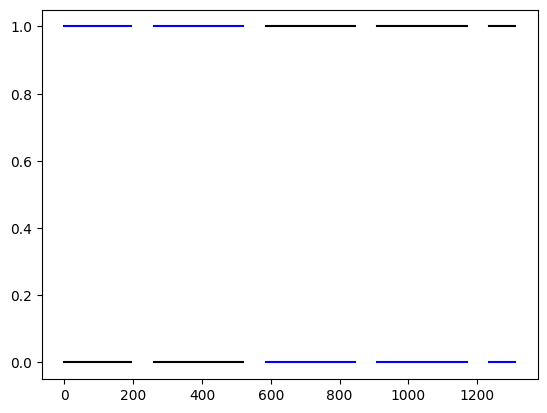

In [113]:
for idx_session, session in enumerate(session_metadata["session_id"]):

    train_idx = train_fold[session]
    model = glm_hmm["session_wise"]["models"][idx_session][best_state][best_fold_session_wise[idx_session]]
    choices = glm_hmm["data"][session]["choices"].values.reshape(-1, 1)
    if "no_bias" in _TRIALS:
        input = np.array(
            glm_hmm["data"][session][
                ["normalized_stimulus"] +
                [f"prev_choice_{t+1}" for t in range(n_trial_back)] +
                [f"prev_target_{t+1}" for t in range(n_trial_back)]
            ]
        )
    else:
        input = np.array(
            glm_hmm["data"][session][
                ["normalized_stimulus", "bias"] +
                [f"prev_choice_{t+1}" for t in range(n_trial_back)] +
                [f"prev_target_{t+1}" for t in range(n_trial_back)]
            ]
        )
    stimulus = glm_hmm["data"][session]["stimulus"]

    mask = glm_hmm["data"][session]["mask"]
    mask = np.ones_like(choices, dtype=bool) if mask is None else mask

    prob_toRF = glm_hmm["data"][session]["prob_toRF"]
    prob_toRF = prob_toRF[mask]
    indices = np.where((prob_toRF != 50) & ~np.isnan(prob_toRF))[0]
    task_switch = indices[0] if len(indices) > 0 else 0
    plt.figure()
    expected_choice_probs, posterior_probs = [],[]
    for idx in train_idx:
        temp_post, temp_choice_prob = get_state_and_choice_probabilities(model, choices[idx], input[idx], mask[idx])
        expected_choice_probs.append(temp_choice_prob)
        posterior_probs.append(temp_post)
        plt.plot(idx,temp_post[:,0], color='k')
        plt.plot(idx,temp_post[:,1], color='b')

    break

    # plot_model_fits(model, choices, input, stimulus, mask, best_state, session, task_switch, trial_indices=train_idx)

### Test Dataset

In [ ]:
for idx_session, session in enumerate(session_metadata["session_id"]):

	test_idx = test_fold[session]
	model = glm_hmm["session_wise"]["models"][idx_session][best_state][best_fold_session_wise[idx_session]]
	choices = glm_hmm["data"][session]["choices"].values.reshape(-1, 1)
	if "no_bias" in _TRIALS:
		input = np.array(
			glm_hmm["data"][session][
				["normalized_stimulus"] +
				[f"prev_choice_{t+1}" for t in range(n_trial_back)] +
				[f"prev_target_{t+1}" for t in range(n_trial_back)]
			]
		)
	else:
		input = np.array(
			glm_hmm["data"][session][
				["normalized_stimulus", "bias"] +
				[f"prev_choice_{t+1}" for t in range(n_trial_back)] +
				[f"prev_target_{t+1}" for t in range(n_trial_back)]
			]
		)
	stimulus = glm_hmm["data"][session]["stimulus"]

	mask = glm_hmm["data"][session]["mask"]
	mask = np.ones_like(choices, dtype=bool) if mask is None else mask

	prob_toRF = glm_hmm["data"][session]["prob_toRF"]
	prob_toRF = prob_toRF[mask]
	indices = np.where((prob_toRF != 50) & ~np.isnan(prob_toRF))[0]
	task_switch = indices[0] if len(indices) > 0 else 0
	plot_model_fits(model, choices, input, stimulus, mask, best_state, session, task_switch, trial_indices=test_idx)

# Fit on whole session and save model

In [ ]:
# get parameter initializations for each session
init_params = {"glm_weights": {}, "transition_matrices": {}}
choices_session_wise, inputs_session_wise, masks_session_wise = [], [], []

# choose best state and best fold model parameters to initialize
for idx_session, session in enumerate(session_metadata["session_id"]):

	init_params["glm_weights"][idx_session] = glm_hmm["session_wise"]["models"][idx_session][best_state][best_fold_session_wise[idx_session]].observations.params
	init_params["transition_matrices"][idx_session] = glm_hmm["session_wise"]["models"][idx_session][best_state][best_fold_session_wise[idx_session]].transitions.params

	choices_session_wise.append(glm_hmm["data"][session]["choices"].values.reshape(-1, 1))
	if "no_bias" in _TRIALS:
		inputs_session_wise.append(np.array(
			glm_hmm["data"][session][
				["normalized_stimulus"] +
				[f"prev_choice_{t+1}" for t in range(n_trial_back)] +
				[f"prev_target_{t+1}" for t in range(n_trial_back)]
			]
		))
	else:
		inputs_session_wise.append(np.array(
			glm_hmm["data"][session][
				["normalized_stimulus", "bias"] +
				[f"prev_choice_{t+1}" for t in range(n_trial_back)] +
				[f"prev_target_{t+1}" for t in range(n_trial_back)]
			]
		))
	masks_session_wise.append(glm_hmm["data"][session]["mask"].values.reshape(-1, 1))

In [ ]:
models_session, fit_ll_session = glm_hmm_utils.session_wise_fit(choices_session_wise, inputs_session_wise, masks=masks_session_wise, n_sessions=len((session_metadata["session_id"])), init_params=init_params, n_states=best_state, n_iters=2500)

models_session_wise, fit_lls_session_wise = {}, {}
for idx_session, session_id in enumerate(session_metadata["session_id"]):
	models_session_wise[session_id] = models_session[idx_session]
	fit_lls_session_wise[session_id] = fit_ll_session[idx_session]

In [ ]:
for idx_session, session in enumerate(session_metadata["session_id"]):
	model = models_session_wise[session]
	choices = glm_hmm["data"][session]["choices"].values.reshape(-1, 1)
	if "no_bias" in _TRIALS:
		input = np.array(
			glm_hmm["data"][session][
				["normalized_stimulus"] +
				[f"prev_choice_{t+1}" for t in range(n_trial_back)] +
				[f"prev_target_{t+1}" for t in range(n_trial_back)]
			]
		)
	else:
		input = np.array(
			glm_hmm["data"][session][
				["normalized_stimulus", "bias"] +
				[f"prev_choice_{t+1}" for t in range(n_trial_back)] +
				[f"prev_target_{t+1}" for t in range(n_trial_back)]
			]
		)
	stimulus = glm_hmm["data"][session]["stimulus"]

	mask = glm_hmm["data"][session]["mask"]
	mask = np.ones_like(choices, dtype=bool) if mask is None else mask

	prob_toRF = glm_hmm["data"][session]["prob_toRF"]
	prob_toRF = prob_toRF[mask]
	indices = np.where((prob_toRF != 50) & ~np.isnan(prob_toRF))[0]
	task_switch = indices[0] if len(indices) > 0 else 0
	plot_model_fits(model, choices, input, stimulus, mask, best_state, session, task_switch)

In [ ]:
with open(Path(processed_dir, f"glm_hmm_{_TRIALS}_final.pkl"), "rb") as f:
	models_and_data = pickle.load(f)
models_session_wise = models_and_data["model"]["models"]
best_state = 2

In [ ]:
fig = plt.figure(figsize=(10, 4))  # Wider figure for better spacing
gs = gridspec.GridSpec(1, best_state)  # Two subplots with equal size

cols = ["#377eb8", "#974810"]  # Colors for awayRF and toRF
legend_added = {0: {cols[0]: False, cols[1]: False}, 1: {cols[0]: False, cols[1]: False}}  # Track legends per subplot

for idx_session, session_id in enumerate(session_metadata["session_id"]):
	model = models_session_wise[session_id]
	glm_weights = -np.array(model.observations.params).reshape(best_state, -1)
	prior_direction = 1 if glm_hmm["data"][session_id]["prob_toRF"].iloc[-1] > 50 else -1

	# if prior_direction == -1:
	# 	glm_weights = np.flip(glm_weights, axis=0)

	for k in range(best_state):
		ax = plt.subplot(gs[k])

		# Determine the color and label
		color = cols[0] if prior_direction == 1 else cols[1]
		label = "toRF prior session" if prior_direction == 1 else "awayRF prior session"

		# Only add legend once per color per subplot
		if not legend_added[k][color]:
			ax.plot(np.arange(2+2*n_trial_back), glm_weights[k], marker="o", color=color, linestyle="-", lw=1.5, label=label)
			legend_added[k][color] = True  # Mark color as used for this subplot
		else:
			ax.plot(np.arange(2+2*n_trial_back), glm_weights[k], marker="o", color=color, linestyle="-", lw=1.5)

		# Formatting
		ax.tick_params(axis="y", labelsize=10)
		ax.set_ylabel("GLM weight", fontsize=15)
		ax.set_xlabel("covariate", fontsize=15)
		ax.set_xticks(range(2+2*n_trial_back))
		ax.set_ylim([-3, 8])
		labels = ["Stimulus", "Bias"] \
			+ [f"Prev Choice {t+1}" for t in range(n_trial_back)] \
			+ [f"Prev Target {t+1}" for t in range(n_trial_back)]

		ax.set_xticklabels(labels, fontsize=12, rotation=15)

		ax.axhline(y=0, color="k", alpha=0.5, ls="--")

		ax.legend()  # Legend appears, but only one instance of each color per subplot
		ax.set_title(f"GLM weights of state {k + 1}", fontsize=15)

plt.show()

In [ ]:
best_state = 2

state_1 = []
state_2 = []

for idx_session, session_id in enumerate(session_metadata["session_id"]):
    model = models_session_wise[session_id]
    glm_weights = -np.array(model.observations.params).reshape(best_state, -1)
    state_1.append(glm_weights[0])
    state_2.append(glm_weights[1])
state_1 = np.array(state_1)
state_2 = np.array(state_2)

In [ ]:
plt.plot(np.mean(state_1, axis=0), label="Biased State", color="#E0590BC1", marker='o', markersize=12, linestyle='-', linewidth=4)
plt.plot(np.mean(state_2, axis=0), label="Unbiased State", color="#0FBD2CE0", marker='o', markersize=12, linestyle='-', linewidth=4)
plt.xticks(np.arange(2+2*n_trial_back), ["Stimulus", "Bias"] + [f"Prev. Choice" for t in range(n_trial_back)] + [f"Prev. Target" for t in range(n_trial_back)], rotation=15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel("Covariates", fontsize=23)
plt.ylabel("GLM Weights", fontsize=23)
# plt.title("GLM Weights for States 1 and 2", fontsize=20)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=18, bbox_to_anchor=(1.2, 1))

In [ ]:
fig = plt.figure(figsize=(10, 4))  # Wider figure for better spacing
gs = gridspec.GridSpec(1, best_state)  # Two subplots with equal size

cols = ["#377eb8", "#974810"]  # Colors for awayRF and toRF
legend_added = {0: {cols[0]: False, cols[1]: False}, 1: {cols[0]: False, cols[1]: False}}  # Track legends per subplot

for idx_session, session_id in enumerate(session_metadata["session_id"]):
	model = models_session_wise[session_id]
	glm_weights = -np.array(model.observations.params).reshape(best_state, -1)
	prior_direction = 1 if glm_hmm["data"][session_id]["prob_toRF"].iloc[-1] > 50 else -1

	# if prior_direction == -1:
	# 	glm_weights = np.flip(glm_weights, axis=0)

	for k in range(best_state):
		ax = plt.subplot(gs[k])

		# Determine the color and label
		color = cols[0] if prior_direction == 1 else cols[1]
		label = "toRF prior session" if prior_direction == 1 else "awayRF prior session"

		# Only add legend once per color per subplot
		if not legend_added[k][color]:
			ax.plot(np.arange(2+2*n_trial_back), glm_weights[k], marker="o", color=color, linestyle="-", lw=1.5, label=label)
			legend_added[k][color] = True  # Mark color as used for this subplot
		else:
			ax.plot(np.arange(2+2*n_trial_back), glm_weights[k], marker="o", color=color, linestyle="-", lw=1.5)

		# Formatting
		ax.tick_params(axis="y", labelsize=10)
		ax.set_ylabel("GLM weight", fontsize=15)
		ax.set_xlabel("covariate", fontsize=15)
		ax.set_xticks(range(2+2*n_trial_back))
		ax.set_ylim([-3, 8])
		labels = ["Stimulus", "Bias"] \
			+ [f"Prev Choice {t+1}" for t in range(n_trial_back)] \
			+ [f"Prev Target {t+1}" for t in range(n_trial_back)]

		ax.set_xticklabels(labels, fontsize=12, rotation=15)

		ax.axhline(y=0, color="k", alpha=0.5, ls="--")

		ax.legend()  # Legend appears, but only one instance of each color per subplot
		ax.set_title(f"GLM weights of state {k + 1}", fontsize=15)

plt.show()

In [ ]:
# # store data and models for session-wise
# session_wise_fits = {
# 	"models": models_session_wise,
# 	"fit_lls": fit_lls_session_wise,
# }

# models_and_data = {
# 	"model": session_wise_fits,
# 	"data": glm_hmm["data"],
# }

# with open(Path(processed_dir, f"glm_hmm_{_TRIALS}_final.pkl"), "wb") as f:
# 	pickle.dump(models_and_data, f)